In [2]:
!pip install torch torchvision

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 13.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 13.6 MB/s eta 0:00:00a 0:00:01
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


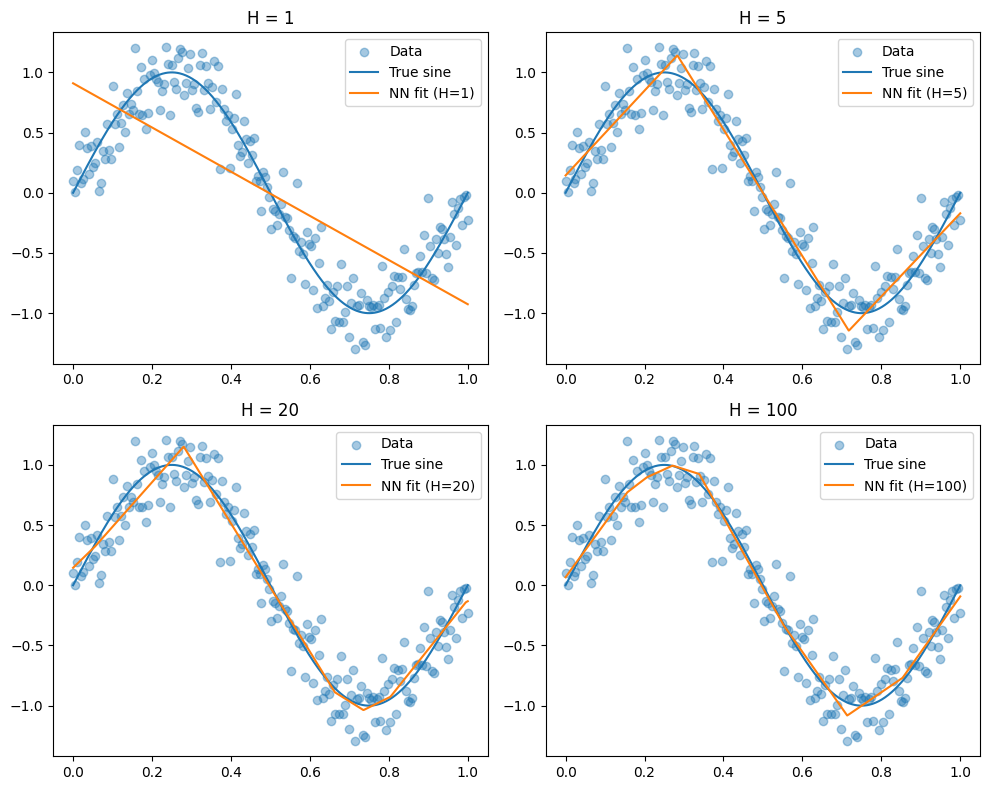

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Data
np.random.seed(42)
torch.manual_seed(42)

X = np.linspace(0, 1, 200).reshape(-1, 1)
y = np.sin(2 * np.pi * X).ravel() + 0.2 * np.random.randn(200)

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

# True function (for plotting)
X_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_true = np.sin(2 * np.pi * X_plot)

# Model
class RegNet(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, H),
            nn.ReLU(),
            nn.Linear(H, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

# Training function
def train_model(H, epochs=7000, lr=0.005):
    model = RegNet(H)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(X_t)
        loss = loss_fn(y_pred, y_t)
        loss.backward()
        optimizer.step()

    return model

# Train models
Hs = [1, 5, 20, 100]
models = {H: train_model(H) for H in Hs}

# Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, H in enumerate(Hs):
    ax = axes[i]
    model = models[H]

    with torch.no_grad():
        y_pred = model(torch.tensor(X_plot, dtype=torch.float32)).numpy()

    ax.scatter(X, y, alpha=0.4, label="Data")
    ax.plot(X_plot, y_true, label="True sine")
    ax.plot(X_plot, y_pred, label=f"NN fit (H={H})")

    ax.set_title(f"H = {H}")
    ax.legend()

plt.tight_layout()
plt.show()

### Discussion
- High-degree polynomials (like in Module 1) overfit because they use global basis functions that create oscillations.
- Neural networks, even with many parameters, often do not overfit because:
 They use local, piecewise-linear basis functions (ReLU)
Gradient-based optimization introduces implicit regularization
The learned function is smooth and low-complexity